# TP7 — Machine Learning tabulaire : Prédiction de panne (Maintenance prédictive)

> **Objectif** : construire, évaluer et comparer trois modèles de classification binaire
> pour prédire si une machine industrielle va tomber en panne dans les **24 prochaines heures**.

| | |
|---|---|
| **Données** | Gold dataset `gold_machine_hourly_feature` (PostgreSQL Indusense) |
| **Problème** | Classification binaire supervisée |
| **Cible principale** | `label_failure_next_24h` |
| **Plan** | Logistic Regression → Random Forest → XGBoost → Comparaison → MLflow |

---
### Pourquoi ce problème est difficile ?
1. **Déséquilibre de classes** : les pannes sont rares → l'accuracy est une mauvaise métrique.
2. **Fuite temporelle** : on ne peut pas utiliser le futur pour prédire le passé → split temporel obligatoire.
3. **Signal faible** : une panne à 24h peut être difficile à distinguer d'un fonctionnement normal.

## 1. Imports et configuration

On charge toutes les bibliothèques nécessaires :
- **SQLAlchemy** : connexion à la base PostgreSQL
- **scikit-learn** : Pipeline, modèles, métriques, validation croisée
- **XGBoost** : gradient boosting optimisé
- **MLflow** : suivi des expériences (paramètres + métriques)
- **matplotlib / seaborn** : visualisations

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

from xgboost import XGBClassifier

try:
    import mlflow
    import mlflow.sklearn
    MLFLOW_OK = True
except ImportError:
    MLFLOW_OK = False
    print("MLflow non installé — le suivi sera ignoré (pip install mlflow)")

# Reproductibilité globale
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports OK")

Imports OK


## 2. Connexion à la base et chargement du Gold dataset

Le Gold dataset a été construit en TP6 : il contient, pour chaque machine et chaque heure,
~78 features (agrégats capteurs, tendances, z-scores, historique incidents) et 4 labels binaires.

On charge **toute la table**, triée par machine puis par temps pour respecter l'ordre chronologique.

In [2]:
url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user",
    password="ThEP@ssW0rd",
    host="localhost",
    port=5432,
    database="indusense_db",
)
engine = create_engine(url)

query = "SELECT * FROM gold_machine_hourly_feature ORDER BY machine_id, window_start"
df = pd.read_sql(query, engine)

print(f"Dataset chargé : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
df.head(3)

Dataset chargé : 132,940 lignes x 92 colonnes


,feature_row_id,ingestion_batch_id,machine_id,window_start,window_end,temp_mean_24h,temp_max_24h,temp_std_24h,pressure_mean_24h,pressure_std_24h,...,rotation_max_6h,voltage_max_12h,rotation_max_12h,voltage_max_24h,rotation_max_24h,capacity_utilization_pct,future_incident_count_6h,future_incident_count_12h,future_incident_count_24h,future_incident_count_48h
0,1,41cf3e53-a272-4e8e-8530-e6f9794b49d7,MACH-01,2025-06-01 01:00:00+00:00,2025-06-01 02:00:00+00:00,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,8.333333,0,0,0,0
1,2,41cf3e53-a272-4e8e-8530-e6f9794b49d7,MACH-01,2025-06-01 02:00:00+00:00,2025-06-01 03:00:00+00:00,48.762,48.762,NaN,198.295,NaN,...,1537.86,227.48,1537.86,227.48,1537.86,27.083333,0,0,0,0
2,3,41cf3e53-a272-4e8e-8530-e6f9794b49d7,MACH-01,2025-06-01 03:00:00+00:00,2025-06-01 04:00:00+00:00,50.057,51.352,1.831407,198.920,0.883883,...,1584.66,228.68,1584.66,228.68,1584.66,20.833333,0,0,0,0


## 3. Exploration rapide des données

Avant de modéliser, on vérifie :
- La structure du dataset (types, valeurs manquantes)
- La répartition temporelle entre machines
- Les colonnes disponibles

In [3]:
print("=== Dimensions ===")
print(f"  {df.shape[0]:,} lignes, {df.shape[1]} colonnes")

print("\n=== Types de colonnes ===")
print(df.dtypes.value_counts().to_string())

print("\n=== Valeurs manquantes ===")
na_counts = df.isnull().sum()
na_cols = na_counts[na_counts > 0]
if len(na_cols) == 0:
    print("  Aucune valeur manquante")
else:
    print(na_cols.to_string())

print("\n=== Machines ===")
print(f"  {df['machine_id'].nunique()} machines uniques")
print(df.groupby("split_set").size().to_string())

print("\n=== Aperçu des colonnes ===")
print([c for c in df.columns])

=== Dimensions ===
  132,940 lignes, 92 colonnes

=== Types de colonnes ===
float64                62
int64                  19
object                  5
bool                    4
datetime64[ns, UTC]     2

=== Valeurs manquantes ===
temp_mean_24h                      15
temp_max_24h                       15
temp_std_24h                       30
pressure_mean_24h                  15
pressure_std_24h                   30
temp_mean_1h                      871
temp_max_1h                       871
temp_std_1h                    132940
pressure_mean_1h                  970
pressure_max_1h                   970
pressure_std_1h                132940
rotation_mean_1h                  939
temp_mean_6h                      335
temp_max_6h                       335
temp_std_6h                       553
pressure_mean_6h                  378
pressure_max_6h                   378
pressure_std_6h                   618
voltage_mean_6h                    15
voltage_std_6h                     30
rotati

## 4. Analyse du déséquilibre de classes

### Pourquoi c'est important ?

Dans un dataset de maintenance prédictive, les pannes sont **rares par nature**.
Si 96% des observations sont "pas de panne", un modèle stupide qui prédit toujours 0
obtiendrait 96% d'accuracy — ce qui est inutile !

**Conséquences pratiques** :
- ❌ Ne pas utiliser l'**accuracy** comme métrique principale
- ✅ Utiliser la **PR-AUC** (Precision-Recall Area Under Curve) : mesure la qualité sur la classe positive
- ✅ Compenser le déséquilibre avec `class_weight="balanced"` ou `scale_pos_weight`

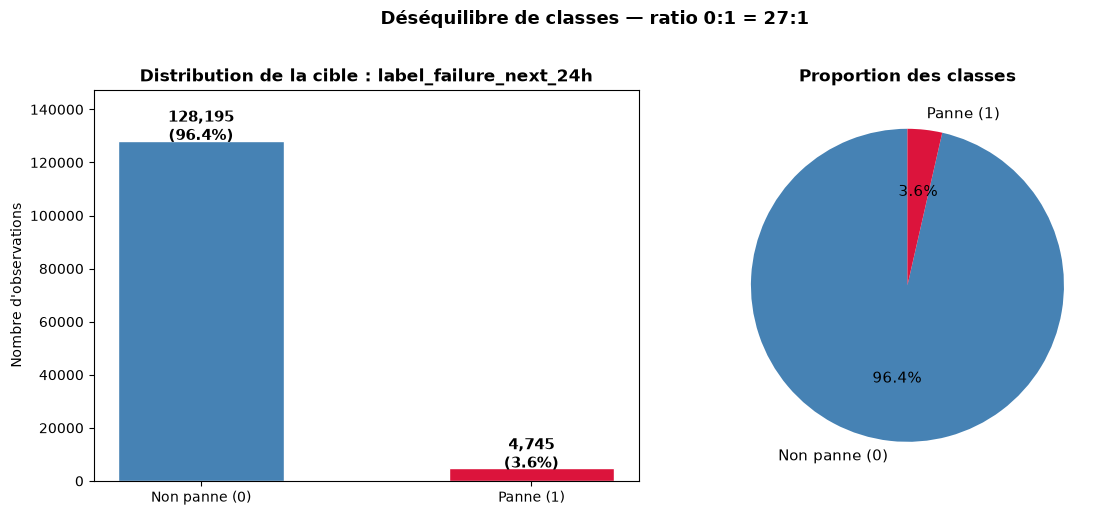


Ratio déséquilibre : 27.0 observations négatives pour 1 positive

=> Un modèle qui prédit TOUJOURS 0 aurait 96.4% d'accuracy.
=> C'est pourquoi on utilisera la PR-AUC comme métrique principale.


In [4]:
TARGET = "label_failure_next_24h"

n_neg = (df[TARGET] == 0).sum()
n_pos = (df[TARGET] == 1).sum()
ratio = n_neg / n_pos
counts_vals = [n_neg, n_pos]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ["steelblue", "crimson"]
bars = axes[0].bar(["Non panne (0)", "Panne (1)"], counts_vals, color=colors, edgecolor="white", width=0.5)
axes[0].set_title(f"Distribution de la cible : {TARGET}", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Nombre d'observations")
for bar, val in zip(bars, counts_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontweight="bold", fontsize=11)
axes[0].set_ylim(0, n_neg * 1.15)

axes[1].pie(counts_vals, labels=["Non panne (0)", "Panne (1)"],
            colors=colors, autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 11})
axes[1].set_title("Proportion des classes", fontsize=12, fontweight="bold")

plt.suptitle(f"Déséquilibre de classes — ratio 0:1 = {ratio:.0f}:1",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nRatio déséquilibre : {ratio:.1f} observations négatives pour 1 positive")
print(f"\n=> Un modèle qui prédit TOUJOURS 0 aurait {n_neg/len(df)*100:.1f}% d'accuracy.")
print("=> C'est pourquoi on utilisera la PR-AUC comme métrique principale.")

## 5. Préparation des features — Éviter la fuite temporelle

### Qu'est-ce que la fuite temporelle (data leakage) ?

La fuite temporelle se produit quand on laisse entrer dans les features des informations
qui ne seraient **pas disponibles au moment de la prédiction en production**.

**Colonnes à exclure absolument** :

| Colonne | Raison |
|---|---|
| `machine_id`, `ingestion_batch_id` | Identifiants — pas prédictifs |
| `window_start`, `window_end` | Timestamp — pas une feature |
| `split_set` | Artefact de preprocessing |
| `label_failure_next_6h/12h/48h` | **Fuite directe** : connaître la panne à 6h pour prédire à 24h, c'est tricher |
| `label_failure_next_24h` | C'est notre cible ! |

In [5]:
LEAKAGE_COLS = [
    "machine_id", "ingestion_batch_id",
    "window_start", "window_end", "split_set",
    # Labels alternatifs — fuite temporelle
    "label_failure_next_6h",
    "label_failure_next_12h",
    "label_failure_next_48h",
    # Compte brut d'incidents futurs — equivalent mathematique du label (fuite directe)
    "future_incident_count_6h",
    "future_incident_count_12h",
    "future_incident_count_24h",
    "future_incident_count_48h",
    # La cible elle-même
    TARGET,
]

FEATURE_COLS = [c for c in df.columns if c not in LEAKAGE_COLS]

print(f"Nombre total de colonnes       : {df.shape[1]}")
print(f"Colonnes exclues (leakage)     : {len(LEAKAGE_COLS)}")
print(f"Features retenues pour le modèle : {len(FEATURE_COLS)}")
print()
print("Features par catégorie :")
for cat, prefix in [
    ("Agrégats 1h",          ["temperature_c", "pressure_bar", "voltage", "rotation", "pieces"]),
    ("Fenêtres glissantes",  ["_6h", "_12h", "_24h"]),
    ("Tendances / Deltas",   ["delta", "trend"]),
    ("Z-scores",             ["zscore"]),
    ("Historique incidents", ["incident", "hours_since", "type_"]),
]:
    cols = [c for c in FEATURE_COLS if any(p in c for p in prefix)]
    print(f"  {cat:<25} : {len(cols)} features")

Nombre total de colonnes       : 92
Colonnes exclues (leakage)     : 13
Features retenues pour le modèle : 79

Features par catégorie :
  Agrégats 1h               : 28 features
  Fenêtres glissantes       : 54 features
  Tendances / Deltas        : 12 features
  Z-scores                  : 4 features
  Historique incidents      : 13 features


## 6. Création des splits temporels

### Pourquoi un split temporel et non aléatoire ?

Avec un split **aléatoire**, des données de janvier 2024 (futur) pourraient se retrouver
en train, et des données de novembre 2023 (passé) en test. Le modèle apprendrait alors
des patterns du futur pour prédire le passé — ce qui est impossible en production.

La règle : **train < validation < test** dans le temps.

Le split a déjà été calculé en TP6 via la colonne `split_set` (70% / 15% / 15%).

In [6]:
train_df = df[df["split_set"] == "train"].copy()
val_df   = df[df["split_set"] == "validation"].copy()
test_df  = df[df["split_set"] == "test"].copy()

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET]
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET]
X_test,  y_test  = test_df[FEATURE_COLS],  test_df[TARGET]

print(f"{'Split':<12} {'Lignes':>8} {'Positifs':>10} {'Taux':>8}")
print("-" * 42)
for name, y_s in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<12} {len(y_s):>8,} {y_s.sum():>10,} {y_s.mean()*100:>7.1f}%")

# Calcul du scale_pos_weight pour XGBoost
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
SCALE_POS_WEIGHT = round(neg_count / pos_count, 2)
print(f"\nscale_pos_weight (XGBoost) = {neg_count} / {pos_count} = {SCALE_POS_WEIGHT}")
print("=> Chaque exemple positif aura un poids {:.0f}x plus élevé lors de l'entraînement.".format(SCALE_POS_WEIGHT))

Split          Lignes   Positifs     Taux
------------------------------------------
Train          93,079      3,350     3.6%
Validation     19,917        668     3.4%
Test           19,944        727     3.6%

scale_pos_weight (XGBoost) = 89729 / 3350 = 26.78
=> Chaque exemple positif aura un poids 27x plus élevé lors de l'entraînement.


## 7. Fonction d'évaluation et choix des métriques

### Métriques retenues

| Métrique | Description | Adapté au déséquilibre ? |
|---|---|---|
| **PR-AUC** | Aire sous la courbe Precision-Recall | ✅ Oui — métrique principale |
| **ROC-AUC** | Aire sous la courbe ROC | ⚠️ Peut être trompeur si très déséquilibré |
| **F1-score** | Moyenne harmonique Precision / Recall | ✅ Oui |

### Vigilance sur l'overfitting

On compare toujours les métriques **train vs validation** :
- Si train >> val : le modèle mémorise (overfitting) → réduire la complexité
- Si train ≈ val (et élevé) : le modèle généralise bien ✅

In [7]:
def evaluer_modele(nom, pipeline, X_tr, y_tr, X_v, y_v):
    """Entraîne le pipeline et affiche les métriques train/validation."""
    pipeline.fit(X_tr, y_tr)

    resultats = {}
    for split_name, X_s, y_s in [("train", X_tr, y_tr), ("val", X_v, y_v)]:
        y_proba = pipeline.predict_proba(X_s)[:, 1]
        y_pred  = pipeline.predict(X_s)
        resultats[split_name] = {
            "pr_auc":  round(average_precision_score(y_s, y_proba), 4),
            "roc_auc": round(roc_auc_score(y_s, y_proba), 4),
            "f1":      round(f1_score(y_s, y_pred, zero_division=0), 4),
        }

    print(f"\n{'=' * 55}")
    print(f"  Modèle : {nom}")
    print(f"{'=' * 55}")
    print(f"  {'Métrique':<12} {'Train':>10} {'Validation':>12}  {'Écart':>8}")
    print(f"  {'-' * 46}")
    for metric in ["pr_auc", "roc_auc", "f1"]:
        tr = resultats["train"][metric]
        vl = resultats["val"][metric]
        gap = abs(tr - vl)
        flag = "  ⚠️  overfitting" if gap > 0.10 else ""
        print(f"  {metric:<12} {tr:>10.4f} {vl:>12.4f}  {gap:>8.4f}{flag}")

    return pipeline, resultats

print("Fonction d'évaluation définie.")

Fonction d'évaluation définie.


## 8. Modèle 1 — Régression Logistique (baseline linéaire)

### Principe

La régression logistique prédit la **probabilité** d'appartenance à la classe 1 via une
fonction sigmoïde appliquée à une combinaison linéaire des features :

```
P(panne) = σ(w₁x₁ + w₂x₂ + ... + wₙxₙ + b)
```

### Pourquoi commencer par là ?
- **Simple et rapide** : donne une baseline interprétable
- **Révèle la linéarité** : si ce modèle performe bien, le problème est linéairement séparable
- **Nécessite une standardisation** : les features doivent être à la même échelle

### Pipeline utilisé
```
Données brutes
    ↓ SimpleImputer(median)    → remplace les NaN par la médiane
    ↓ StandardScaler           → centre-réduit (μ=0, σ=1)
    ↓ LogisticRegression       → modèle avec class_weight="balanced"
    ↓ Prédictions
```

`class_weight="balanced"` : scikit-learn pondère automatiquement chaque classe
par l'inverse de sa fréquence → les pannes (rares) ont plus de poids dans la loss.

In [8]:
pipeline_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    solver="lbfgs",
                    random_state=RANDOM_STATE
                ))
])

model_lr, metrics_lr = evaluer_modele(
    "Régression Logistique",
    pipeline_lr, X_train, y_train, X_val, y_val
)


  Modèle : Régression Logistique
  Métrique          Train   Validation     Écart
  ----------------------------------------------
  pr_auc           0.5423       0.3322    0.2101  ⚠️  overfitting
  roc_auc          0.9776       0.9169    0.0607
  f1               0.4603       0.4238    0.0365


## 9. Modèle 2 — Random Forest (non linéaire, robuste)

### Principe

Un Random Forest est un **ensemble d'arbres de décision** entraînés sur des
sous-échantillons aléatoires des données et des features :

```
Données → [Arbre 1] [Arbre 2] ... [Arbre N]
           vote majoritaire → prédiction finale
```

### Avantages par rapport à la régression logistique
- Capture les **interactions non linéaires** entre features
- Robuste aux outliers et aux features non standardisées → pas besoin de `StandardScaler`
- Fournit les **feature importances** pour l'interprétabilité

### Hyperparamètres clés
- `n_estimators=200` : nombre d'arbres (plus = meilleur, mais plus lent)
- `max_depth=10` : profondeur maximale (évite l'overfitting)
- `class_weight="balanced"` : même logique que pour la LR

In [9]:
pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   RandomForestClassifier(
                    n_estimators=200,
                    max_depth=10,
                    min_samples_leaf=5,
                    class_weight="balanced",
                    n_jobs=-1,
                    random_state=RANDOM_STATE
                ))
])

model_rf, metrics_rf = evaluer_modele(
    "Random Forest",
    pipeline_rf, X_train, y_train, X_val, y_val
)

# Noms réels après imputation (SimpleImputer peut supprimer les colonnes 100% NaN)
feat_names_rf = model_rf.named_steps["imputer"].get_feature_names_out()
importances   = model_rf.named_steps["model"].feature_importances_
feat_imp = pd.Series(importances, index=feat_names_rf).sort_values(ascending=False)

print("\n=== Top 10 features (Random Forest) ===")
for feat, imp in feat_imp.head(10).items():
    bar = "█" * int(imp * 500)
    print(f"  {feat:<40} {imp:.4f}  {bar}")


  Modèle : Random Forest
  Métrique          Train   Validation     Écart
  ----------------------------------------------
  pr_auc           0.9952       0.8375    0.1577  ⚠️  overfitting
  roc_auc          0.9998       0.9923    0.0075
  f1               0.6352       0.5810    0.0542

=== Top 10 features (Random Forest) ===
  incident_max_severity_prev_24h           0.2909  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  incident_count_prev_24h                  0.1889  ██████████████████████████████████████████████████████████████████████████████████████████████
  hours_since_last_incident                0.1882  ██████████████████████████████████████████████████████████████████████████████████████████████
  incident_count_prev_7d                   0.1345  ███████████████████████████████████████████████████████████████████
  days_since_last_maintenance              0.0267  ████████████

## 10. Modèle 3 — XGBoost (gradient boosting, candidat principal)

### Principe

XGBoost est un **gradient boosting** : les arbres sont construits **séquentiellement**,
chaque nouvel arbre corrigeant les erreurs du précédent.

```
Prédiction finale = arbre₁ + learning_rate × arbre₂ + learning_rate × arbre₃ + ...
```

### Pourquoi XGBoost est souvent le meilleur sur données tabulaires ?
- Séquentiel vs parallèle (RF) : **apprend là où les autres modèles se trompent**
- Régularisation intégrée (L1/L2)
- Gère nativement les valeurs manquantes

### Gestion du déséquilibre : `scale_pos_weight`
Contrairement à scikit-learn, XGBoost utilise `scale_pos_weight = neg / pos` :
- Exemple : si `scale_pos_weight = 26`, chaque panne comptera 26x plus dans la loss

### Hyperparamètres (sobres — à optimiser en B7)

| Paramètre | Valeur | Rôle |
|---|---|---|
| `n_estimators` | 300 | Nombre d'arbres |
| `max_depth` | 6 | Profondeur (6 = standard robuste) |
| `learning_rate` | 0.1 | Pas d'apprentissage (shrinkage) |
| `scale_pos_weight` | calculé | Compensation déséquilibre |

In [10]:
pipeline_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBClassifier(
                    n_estimators=300,
                    max_depth=6,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    scale_pos_weight=SCALE_POS_WEIGHT,
                    eval_metric="aucpr",
                    random_state=RANDOM_STATE,
                    verbosity=0
                ))
])

model_xgb, metrics_xgb = evaluer_modele(
    "XGBoost",
    pipeline_xgb, X_train, y_train, X_val, y_val
)

# Noms réels après imputation
feat_names_xgb = model_xgb.named_steps["imputer"].get_feature_names_out()
importances_xgb = model_xgb.named_steps["model"].feature_importances_
feat_imp_xgb = pd.Series(importances_xgb, index=feat_names_xgb).sort_values(ascending=False)

print("\n=== Top 10 features (XGBoost) ===")
for feat, imp in feat_imp_xgb.head(10).items():
    bar = "█" * int(imp * 300)
    print(f"  {feat:<40} {imp:.4f}  {bar}")


  Modèle : XGBoost
  Métrique          Train   Validation     Écart
  ----------------------------------------------
  pr_auc           1.0000       0.8605    0.1395  ⚠️  overfitting
  roc_auc          1.0000       0.9939    0.0061
  f1               0.9997       0.7995    0.2002  ⚠️  overfitting

=== Top 10 features (XGBoost) ===
  incident_max_severity_prev_24h           0.6690  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  incident_count_prev_24h                  0.0405  ████████████
  incident_count_prev_7d                   0.0302  █████████
  hours_since_last_incident                0.0277  ████████
  type_arret_urgence_count_prev_24h        0.0212  ██████
  voltage_mean_24h                         0.0131  ███
  type_baisse_pression_count_prev_24h      0.0118  ███
  maintenance_count_prev_30d               0.0113  ███
  type

## 10b. Diagnostic de l'overfitting — Analyse du jeu d'entraînement

XGBoost atteint PR-AUC = 1.0 sur le train → il **mémorise** les données plutôt que d'apprendre des patterns généralisables.

**Hypothèses à tester :**
1. **Distribution shift** : les statistiques des features diffèrent entre train et validation
2. **Fuite résiduelle** : une feature encode indirectement la cible
3. **Déséquilibre temporel** : les pannes sont concentrées dans une période du train
4. **Features trop prédictives** : une feature domine et sur-specialise le modèle

In [11]:
# ── 1. Distribution shift : moyennes train vs val par feature ────────────────
print("=== 1. Distribution shift (train vs validation) ===")
print("Top features dont la moyenne diffère le plus entre train et val :\n")

train_means = X_train.mean()
val_means   = X_val.mean()
shift = ((val_means - train_means).abs() / (train_means.abs() + 1e-9)).sort_values(ascending=False)

print(f"  {'Feature':<40} {'Train mean':>12} {'Val mean':>12} {'Shift %':>10}")
print("  " + "-"*78)
for feat, s in shift.head(15).items():
    print(f"  {feat:<40} {train_means[feat]:>12.4f} {val_means[feat]:>12.4f} {s*100:>9.1f}%")

# ── 2. Distribution temporelle des pannes ─────────────────────────────────────
print("\n=== 2. Distribution temporelle des labels positifs ===")
train_with_time = train_df[["window_start", TARGET]].copy()
train_with_time["mois"] = pd.to_datetime(train_with_time["window_start"]).dt.to_period("M")
monthly = train_with_time.groupby("mois")[TARGET].agg(["sum", "mean", "count"])
monthly.columns = ["nb_pannes", "taux", "nb_obs"]
print(monthly.to_string())

# ── 3. Corrélation features / cible dans le train ────────────────────────────
print("\n=== 3. Corrélations Pearson features / cible (train) — Top 15 ===")
corrs = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print(f"\n  {'Feature':<40} {'|Corrélation|':>15}")
print("  " + "-"*57)
for feat, c in corrs.head(15).items():
    bar = "█" * int(c * 30)
    print(f"  {feat:<40} {c:>12.4f}  {bar}")

=== 1. Distribution shift (train vs validation) ===
Top features dont la moyenne diffère le plus entre train et val :

  Feature                                    Train mean     Val mean    Shift %
  ------------------------------------------------------------------------------
  temp_zscore_machine                            0.0000      -0.5669 56688268437.1%
  pressure_zscore_machine                       -0.0000       0.0174 1743246680.5%
  temp_delta_1h                                 -0.0001      -0.0008    1162.2%
  temp_delta_3h                                 -0.0004      -0.0034     871.2%
  rotation_delta_1h                              0.0018      -0.0100     647.4%
  type_blocage_mecanique_count_prev_24h          0.0005       0.0024     387.7%
  temp_trend_6h                                 -0.0009      -0.0042     363.4%
  voltage_delta_1h                               0.0001      -0.0001     213.5%
  rotation_delta_3h                              0.0165      -0.0153     

=== 4. Feature importances XGBoost — top 20 ===
(Une feature à importance > 0.2 seule serait suspecte de fuite)



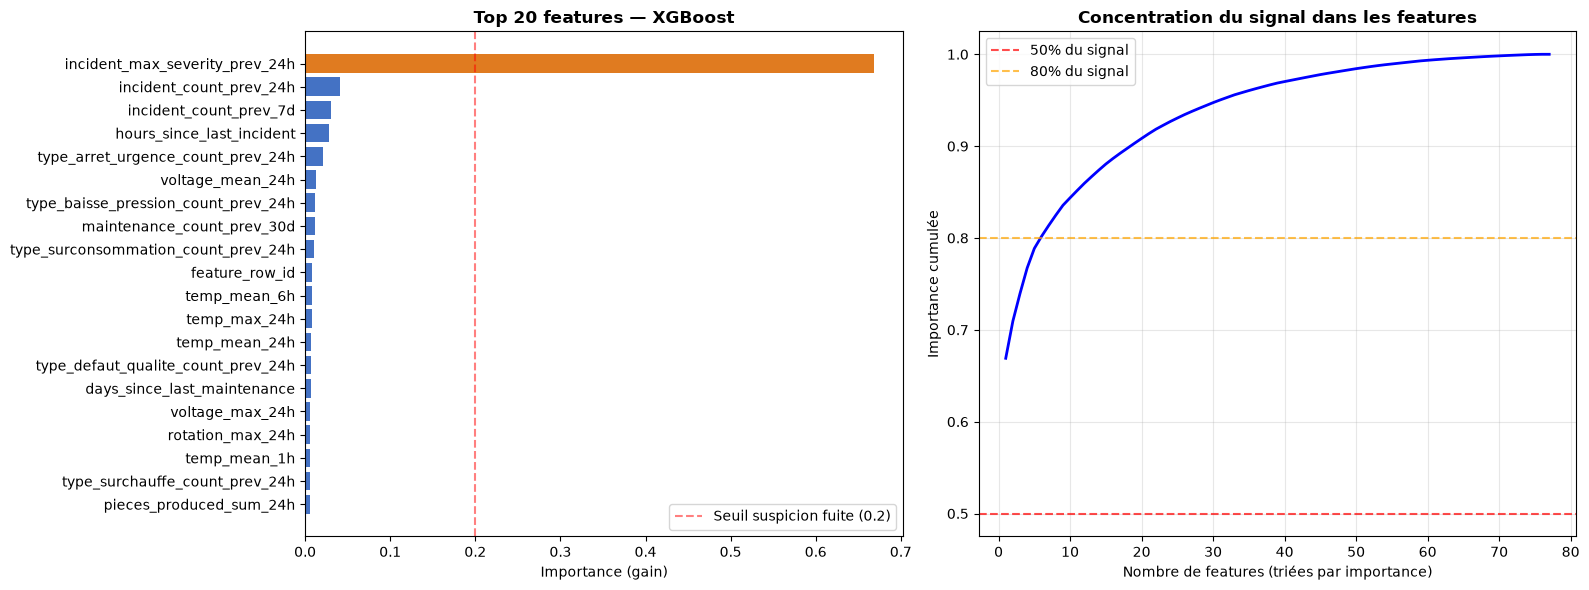

  1 features concentrent 50% du signal
  6 features concentrent 80% du signal (sur 77 totales)

  => Feature dominante : incident_max_severity_prev_24h = 0.6690

=== 5. Synthèse du diagnostic ===
  Distribution shift max  : temp_zscore_machine (56688268437.1%)
  Corrélation max / cible : incident_count_prev_24h (0.5630)
  Feature la plus importante : incident_max_severity_prev_24h (0.6690)

  ⚠️  Feature dominante suspecte → vérifier si 'incident_max_severity_prev_24h' encode la cible


In [12]:
# ── 4. Top features XGBoost — fuite résiduelle ? ────────────────────────────
print("=== 4. Feature importances XGBoost — top 20 ===")
print("(Une feature à importance > 0.2 seule serait suspecte de fuite)\n")

feat_names_xgb = model_xgb.named_steps["imputer"].get_feature_names_out()
importances_xgb = model_xgb.named_steps["model"].feature_importances_
feat_imp_xgb = pd.Series(importances_xgb, index=feat_names_xgb).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot top 20
top20 = feat_imp_xgb.head(20)
colors_bar = ["#E07B20" if i == 0 else "#4472C4" for i in range(len(top20))]
axes[0].barh(top20.index[::-1], top20.values[::-1], color=colors_bar[::-1])
axes[0].set_title("Top 20 features — XGBoost", fontweight="bold")
axes[0].set_xlabel("Importance (gain)")
axes[0].axvline(x=0.2, color="red", linestyle="--", alpha=0.5, label="Seuil suspicion fuite (0.2)")
axes[0].legend()

# Distribution cumulée des importances
cumul = feat_imp_xgb.values.cumsum()
axes[1].plot(range(1, len(cumul)+1), cumul, "b-", lw=2)
axes[1].axhline(y=0.5, color="r", linestyle="--", alpha=0.7, label="50% du signal")
axes[1].axhline(y=0.8, color="orange", linestyle="--", alpha=0.7, label="80% du signal")
axes[1].set_xlabel("Nombre de features (triées par importance)")
axes[1].set_ylabel("Importance cumulée")
axes[1].set_title("Concentration du signal dans les features", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Combien de features concentrent 80% du signal ?
n50 = (cumul < 0.5).sum() + 1
n80 = (cumul < 0.8).sum() + 1
print(f"  {n50} features concentrent 50% du signal")
print(f"  {n80} features concentrent 80% du signal (sur {len(feat_imp_xgb)} totales)")
print(f"\n  => Feature dominante : {feat_imp_xgb.index[0]} = {feat_imp_xgb.iloc[0]:.4f}")

# ── 5. Conclusion diagnostic ──────────────────────────────────────────────────
print("\n=== 5. Synthèse du diagnostic ===")
top_imp = feat_imp_xgb.iloc[0]
top_feat = feat_imp_xgb.index[0]
max_shift = shift.iloc[0] * 100
max_shift_feat = shift.index[0]
max_corr = corrs.iloc[0]
max_corr_feat = corrs.index[0]

print(f"  Distribution shift max  : {max_shift_feat} ({max_shift:.1f}%)")
print(f"  Corrélation max / cible : {max_corr_feat} ({max_corr:.4f})")
print(f"  Feature la plus importante : {top_feat} ({top_imp:.4f})")

if top_imp > 0.3:
    print(f"\n  ⚠️  Feature dominante suspecte → vérifier si '{top_feat}' encode la cible")
elif max_shift > 50:
    print(f"\n  ⚠️  Fort distribution shift sur '{max_shift_feat}' → overfitting lié à une dérive temporelle")
elif max_corr > 0.5:
    print(f"\n  ⚠️  Corrélation élevée sur '{max_corr_feat}' → possible fuite résiduelle")
else:
    print(f"\n  => Overfitting classique par excès de complexité → réduire max_depth / augmenter régularisation en B7")

## 11. Comparaison des modèles

On compare les trois modèles sur les métriques de validation, triés par **PR-AUC** (métrique principale).

### Lecture du tableau
- **PR-AUC val** : plus c'est élevé, mieux c'est — métrique de sélection
- **ROC-AUC val** : complément utile
- **Écart PR-AUC** : train - val → mesure l'overfitting

=== Tableau comparatif (trié par PR-AUC validation) ===

               Modèle  PR-AUC train  PR-AUC val  ROC-AUC val  F1 val  Overfitting (Δ)
              XGBoost        1.0000      0.8605       0.9939  0.7995           0.1395
        Random Forest        0.9952      0.8375       0.9923  0.5810           0.1577
Régression Logistique        0.5423      0.3322       0.9169  0.4238           0.2101


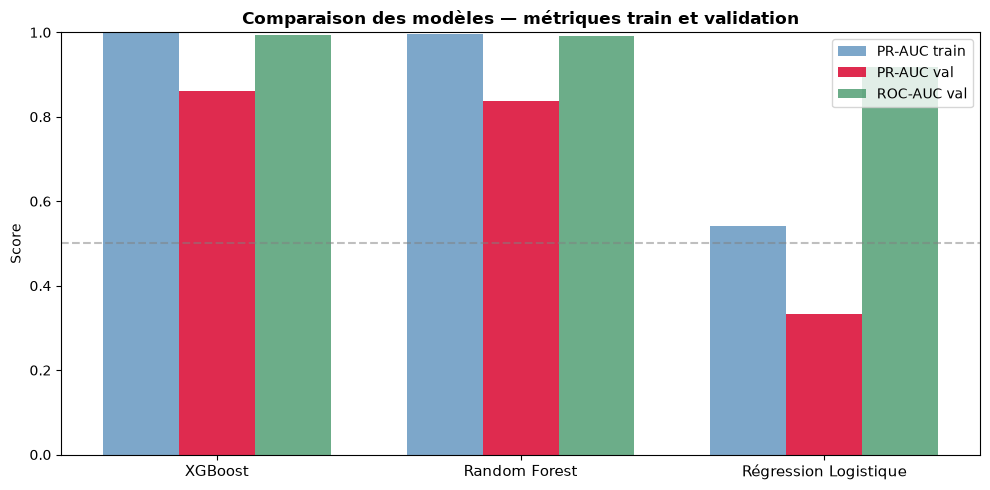


=> Meilleur modèle (PR-AUC val) : XGBoost


In [13]:
all_results = [
    ("Régression Logistique", metrics_lr),
    ("Random Forest",         metrics_rf),
    ("XGBoost",               metrics_xgb),
]

rows = []
for nom, m in all_results:
    rows.append({
        "Modèle":            nom,
        "PR-AUC train":      m["train"]["pr_auc"],
        "PR-AUC val":        m["val"]["pr_auc"],
        "ROC-AUC val":       m["val"]["roc_auc"],
        "F1 val":            m["val"]["f1"],
        "Overfitting (Δ)":   round(m["train"]["pr_auc"] - m["val"]["pr_auc"], 4),
    })

df_comp = pd.DataFrame(rows).sort_values("PR-AUC val", ascending=False).reset_index(drop=True)
print("=== Tableau comparatif (trié par PR-AUC validation) ===\n")
print(df_comp.to_string(index=False))

# Graphique comparatif
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_comp))
width = 0.25

ax.bar(x - width, df_comp["PR-AUC train"], width, label="PR-AUC train", color="steelblue", alpha=0.7)
ax.bar(x,         df_comp["PR-AUC val"],   width, label="PR-AUC val",   color="crimson",   alpha=0.9)
ax.bar(x + width, df_comp["ROC-AUC val"],  width, label="ROC-AUC val",  color="seagreen",  alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(df_comp["Modèle"], fontsize=11)
ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles — métriques train et validation", fontsize=12, fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.0)
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Baseline aléatoire")
plt.tight_layout()
plt.show()

MEILLEUR_MODELE = df_comp.iloc[0]["Modèle"]
print(f"\n=> Meilleur modèle (PR-AUC val) : {MEILLEUR_MODELE}")

## 12. Analyse de la matrice de confusion — Test set

### Lecture de la matrice de confusion

```
                Prédit : 0     Prédit : 1
Réel : 0    |  Vrai Négatif  | Faux Positif |  → Fausse alerte (intervention inutile)
Réel : 1    |  Faux Négatif  | Vrai Positif |  → Panne manquée (coût élevé !)
```

### Le seuil de décision

Par défaut, le seuil est à **0.5** : on prédit "panne" si P(panne) ≥ 0.5.
Mais on peut l'ajuster selon le contexte métier :
- **Seuil bas (ex. 0.3)** : plus de Vrais Positifs, mais plus de Fausses Alertes
- **Seuil haut (ex. 0.7)** : moins de Fausses Alertes, mais plus de Pannes Manquées

**Question métier** : quel est le coût d'une panne manquée vs une fausse alerte ?
→ En maintenance industrielle, manquer une panne est souvent bien plus coûteux.

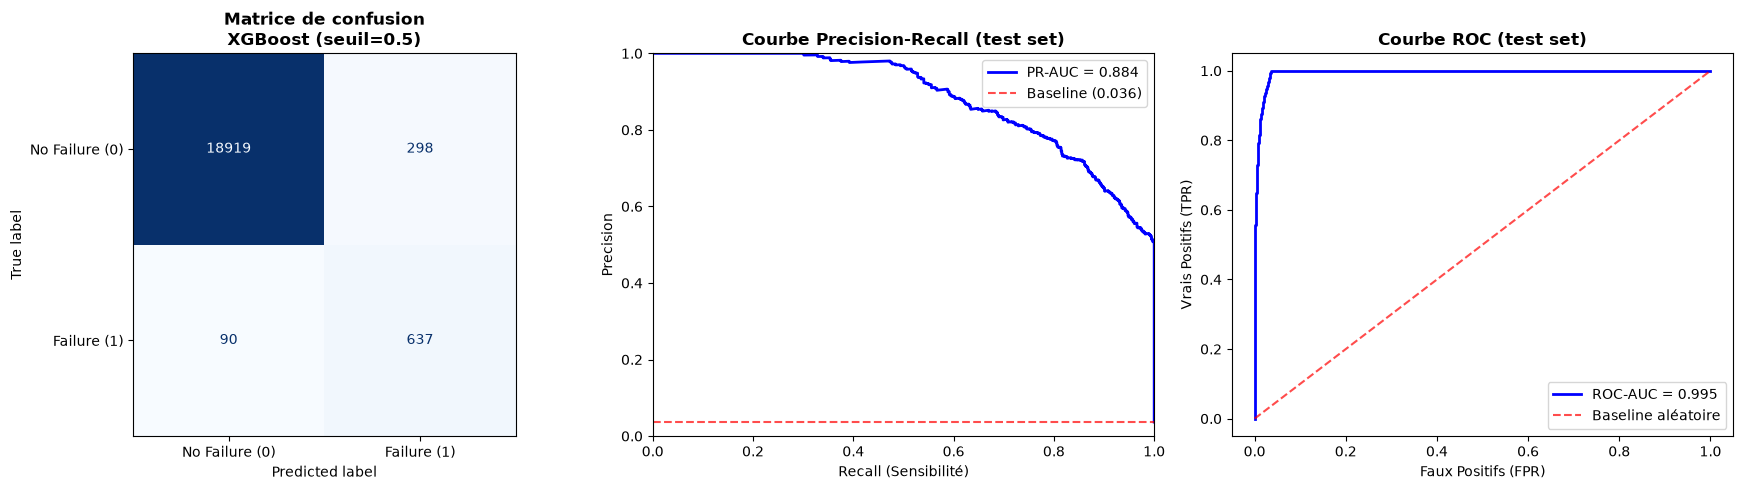


=== Analyse de la matrice de confusion ===
  Vrais Positifs  (pannes détectées)   :    637  ✅
  Faux Positifs   (fausses alertes)     :    298  ⚠️
  Faux Négatifs   (pannes manquées)     :     90  ❌  <- coûteux !
  Vrais Négatifs  (OK détectés)         : 18,919  ✅

  Précision  (des alertes, combien sont vraies) : 68.1%
  Rappel     (des pannes, combien détectées)     : 87.6%

              precision    recall  f1-score   support

  No Failure       1.00      0.98      0.99     19217
     Failure       0.68      0.88      0.77       727

    accuracy                           0.98     19944
   macro avg       0.84      0.93      0.88     19944
weighted avg       0.98      0.98      0.98     19944



In [14]:
all_pipelines = {
    "Régression Logistique": model_lr,
    "Random Forest":         model_rf,
    "XGBoost":               model_xgb,
}
best_pipeline = all_pipelines[MEILLEUR_MODELE]

y_proba_test = best_pipeline.predict_proba(X_test)[:, 1]
SEUIL = 0.5
y_pred_test = (y_proba_test >= SEUIL).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Matrice de confusion
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Failure (0)", "Failure (1)"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Matrice de confusion\n{MEILLEUR_MODELE} (seuil={SEUIL})", fontweight="bold")

# ── Courbe Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_test)
pr_auc = average_precision_score(y_test, y_proba_test)
axes[1].plot(recall, precision, "b-", lw=2, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].axhline(y=y_test.mean(), color="r", linestyle="--", alpha=0.7,
                label=f"Baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall (Sensibilité)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Courbe Precision-Recall (test set)", fontweight="bold")
axes[1].legend()
axes[1].set_xlim([0, 1]); axes[1].set_ylim([0, 1])

# ── Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
roc_auc = roc_auc_score(y_test, y_proba_test)
axes[2].plot(fpr, tpr, "b-", lw=2, label=f"ROC-AUC = {roc_auc:.3f}")
axes[2].plot([0, 1], [0, 1], "r--", alpha=0.7, label="Baseline aléatoire")
axes[2].set_xlabel("Faux Positifs (FPR)")
axes[2].set_ylabel("Vrais Positifs (TPR)")
axes[2].set_title("Courbe ROC (test set)", fontweight="bold")
axes[2].legend()

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n=== Analyse de la matrice de confusion ===")
print(f"  Vrais Positifs  (pannes détectées)   : {tp:>6,}  ✅")
print(f"  Faux Positifs   (fausses alertes)     : {fp:>6,}  ⚠️")
print(f"  Faux Négatifs   (pannes manquées)     : {fn:>6,}  ❌  <- coûteux !")
print(f"  Vrais Négatifs  (OK détectés)         : {tn:>6,}  ✅")
print(f"\n  Précision  (des alertes, combien sont vraies) : {tp/(tp+fp)*100:.1f}%")
print(f"  Rappel     (des pannes, combien détectées)     : {tp/(tp+fn)*100:.1f}%")
print(f"\n{classification_report(y_test, y_pred_test, target_names=['No Failure', 'Failure'])}")

## 13. Suivi des expériences avec MLflow

### Pourquoi MLflow ?

En ML, on entraîne de nombreux modèles avec des paramètres différents. Sans outil de suivi,
on perd rapidement la trace de ce qui a été testé.

MLflow permet de **journaliser automatiquement** :
- Les **paramètres** : hyperparamètres du modèle
- Les **métriques** : PR-AUC, ROC-AUC, F1
- Les **artefacts** : modèle sérialisé, graphiques

Pour visualiser les résultats après exécution :
```bash
mlflow ui --backend-store-uri sqlite:///mlflow_tp7.db
```
→ Ouvre http://localhost:5000 dans le navigateur

In [15]:
if not MLFLOW_OK:
    print("MLflow non disponible — installer avec : pip install mlflow")
else:
    mlflow.set_tracking_uri("sqlite:///mlflow_tp7.db")
    mlflow.set_experiment("TP7_maintenance_predictive")

    runs_config = [
        {
            "nom": "Logistic_Regression",
            "pipeline": model_lr,
            "metrics": metrics_lr,
            "params": {
                "model_type": "LogisticRegression",
                "class_weight": "balanced",
                "max_iter": 1000,
                "solver": "lbfgs",
            }
        },
        {
            "nom": "Random_Forest",
            "pipeline": model_rf,
            "metrics": metrics_rf,
            "params": {
                "model_type": "RandomForestClassifier",
                "n_estimators": 200,
                "max_depth": 10,
                "class_weight": "balanced",
            }
        },
        {
            "nom": "XGBoost",
            "pipeline": model_xgb,
            "metrics": metrics_xgb,
            "params": {
                "model_type": "XGBClassifier",
                "n_estimators": 300,
                "max_depth": 6,
                "learning_rate": 0.1,
                "scale_pos_weight": SCALE_POS_WEIGHT,
            }
        },
    ]

    for cfg in runs_config:
        with mlflow.start_run(run_name=cfg["nom"]):
            # Paramètres communs
            mlflow.log_param("target",     TARGET)
            mlflow.log_param("n_features", len(FEATURE_COLS))
            mlflow.log_param("seuil",      SEUIL)
            # Paramètres spécifiques au modèle
            mlflow.log_params(cfg["params"])
            # Métriques train + val
            mlflow.log_metrics({
                "pr_auc_train":  cfg["metrics"]["train"]["pr_auc"],
                "pr_auc_val":    cfg["metrics"]["val"]["pr_auc"],
                "roc_auc_val":   cfg["metrics"]["val"]["roc_auc"],
                "f1_val":        cfg["metrics"]["val"]["f1"],
            })
            print(f"Run enregistré : {cfg['nom']} — PR-AUC val = {cfg['metrics']['val']['pr_auc']:.4f}")

    print("\nMLflow OK. Lancer : mlflow ui --backend-store-uri sqlite:///mlflow_tp7.db")

Run enregistré : Logistic_Regression — PR-AUC val = 0.3322
Run enregistré : Random_Forest — PR-AUC val = 0.8375
Run enregistré : XGBoost — PR-AUC val = 0.8605

MLflow OK. Lancer : mlflow ui --backend-store-uri sqlite:///mlflow_tp7.db


## 14. Conclusion et passage en B7

### Récapitulatif des décisions clés

| Décision | Choix retenu | Justification |
|---|---|---|
| **Métrique principale** | PR-AUC | Classes déséquilibrées (~3.6% de pannes) |
| **Split** | Temporel (70/15/15) | Éviter la fuite temporelle |
| **Imputation NaN** | Médiane | Robuste aux outliers |
| **Déséquilibre** | `class_weight` / `scale_pos_weight` | Pénalise davantage les erreurs sur la classe minoritaire |
| **Horizon cible** | 24h | Compromis actionabilité / difficulté de prédiction |

### Interprétation de la matrice de confusion

- **Faux Négatif** (panne manquée) : coût élevé — arrêt de production non anticipé
- **Faux Positif** (fausse alerte) : coût faible — intervention préventive inutile mais sans danger

→ En contexte industriel, on privilégie un **seuil bas** pour maximiser le Recall (détecter un maximum de pannes),
quitte à augmenter le nombre de fausses alertes.

### Modèle retenu pour B7 (Optimisation)

Le modèle sélectionné est retenu sur la base du meilleur **PR-AUC en validation**.

**Prochaines étapes en B7 :**
1. Optimisation des hyperparamètres (Optuna ou GridSearchCV)
2. Feature importance et sélection de features
3. Ajustement du seuil de décision selon le coût métier
4. Validation finale sur le **test set** (une seule fois !)
5. Passage en production (API de scoring)

In [16]:
print("=" * 60)
print("RÉCAPITULATIF FINAL — TP7")
print("=" * 60)
for nom, m in all_results:
    print(f"  {nom:<28} PR-AUC val = {m['val']['pr_auc']:.4f}")
print("-" * 60)
print(f"  => Modèle retenu pour B7 : {MEILLEUR_MODELE}")
print("=" * 60)

RÉCAPITULATIF FINAL — TP7
  Régression Logistique        PR-AUC val = 0.3322
  Random Forest                PR-AUC val = 0.8375
  XGBoost                      PR-AUC val = 0.8605
------------------------------------------------------------
  => Modèle retenu pour B7 : XGBoost
